# Policy Gradient Training

In [1]:
import gym
import time
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from narla.node import Node
from narla.utils import pg_action_loss
from narla.man import MultiAgentNetwork

tf.random.set_seed(123)
tf.keras.backend.set_floatx('float32')

In [2]:
env = gym.make("CartPole-v1")
state = tf.convert_to_tensor(
    env.reset().reshape(1, -1),
    dtype=tf.float32
)

### PG for Single Node in MAN Paradigm

In [3]:
man = MultiAgentNetwork(
    input_size=4, 
    num_layers=2, 
    num_nodes_per_layer=10
)

In [4]:
update_every = 10
num_episodes = 100
all_episode_rewards = []
for episode in range(1, num_episodes):
  
    done = False
    state = tf.convert_to_tensor(
        env.reset().reshape(1, -1),
        dtype=tf.float32
    )
    total_reward = 0
    rewards = []
    actions = []
    probs = []
    
    while not done:
        action = int(man(state).numpy()[0])
        
        next_state, reward, done, _ = env.step(action)
        next_state = tf.convert_to_tensor(
            next_state.reshape(1, -1), 
            dtype=tf.float32
        )
        rewards.append(reward)
        actions.append(action)
        man.record_reward(reward)
        
        state = next_state
        total_reward += reward
        
        if done:
            man.learn()
            if episode % update_every == 0:
                print(f'Episode: {episode} Reward: {np.mean(all_episode_rewards[-update_every:])}')
            
    all_episode_rewards.append(total_reward)

Episode: 10 Reward: 22.555555555555557
Episode: 20 Reward: 33.2
Episode: 30 Reward: 62.8
Episode: 40 Reward: 124.9
Episode: 50 Reward: 120.3
Episode: 60 Reward: 125.6
Episode: 70 Reward: 253.6
Episode: 80 Reward: 491.6
Episode: 90 Reward: 408.8


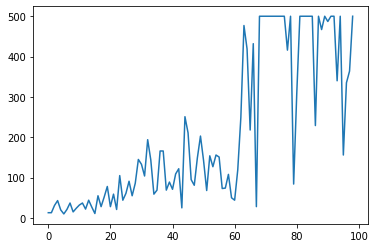

In [5]:
plt.plot(all_episode_rewards)

### PG for Single Node

In [ ]:
node = Node(name='TestNode')
node(state)

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)

def train(tapes, probs, rewards, actions):
    sum_reward = 0
    discnt_rewards = []
    rewards.reverse()
    for r in rewards:
        sum_reward = r + .99*sum_reward
        discnt_rewards.append(sum_reward)
        
    discnt_rewards.reverse()  

    for tape, prob, reward, action in zip(tapes, probs, discnt_rewards, actions):
        with node.name_scope:
            tape.__enter__()
            loss = pg_action_loss(prob, action, reward)
            tape.__exit__(None, None, None)

            grads = tape.gradient(loss, node.trainable_variables)
            opt.apply_gradients(zip(grads, node.trainable_variables))

In [ ]:
num_episodes = 5000
all_episode_rewards = []
for episode in range(num_episodes):
  
    done = False
    state = tf.convert_to_tensor(
        env.reset().reshape(1, -1)
    )
    total_reward = 0
    rewards = []
    actions = []
    tapes = []
    probs = []
    
    while not done:
        with tf.GradientTape(persistent=True) as tape:
            action, prob = node(state)
            
        tapes.append(tape)
        probs.append(prob)
        
        next_state, reward, done, _ = env.step(int(action.numpy()[0]))
        next_state = tf.convert_to_tensor(
            next_state.reshape(1, -1)
        )
        rewards.append(reward)
        actions.append(action)
        
        state = next_state
        total_reward += reward

        if done:
            train(tapes, probs, rewards, actions)
            #print("total step for this episord are {}".format(t))
            if episode % 25 == 0:
                print(f'Episode: {episode} Reward: {total_reward}')
            
    all_episode_rewards.append(total_reward)

In [ ]:
plt.plot(all_episode_rewards)